<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/UdeC_color_horizontal.jpg" width="500">
</p>
<p align="center"><b style="font-size:28px;">Facultad de Ingeniería Agrícola</b></p>
<p align="center"><b style="font-size:28px;">Curso de Hidrología</b></p>
<hr>
<p align="center"><b style="font-size:28px;">Contacto</b></p>
<p align="center">
  paulmunoz@udec.cl<br>
  https://paulmunoz.com
</p>

# Precipitación

## Objetivo

Procesar datos pluviométricos de una estación real en Chile.


## Clonar el repositorio desde GitHub

In [40]:
# Clonar el repositorio desde GitHub
!git clone -- https://github.com/paulmunozpauta/Hidrology_Course

Cloning into 'Hidrology_Course'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 151 (delta 48), reused 38 (delta 8), pack-reused 38 (from 1)
Receiving objects: 100% (151/151), 63.93 MiB | 24.97 MiB/s, done.
Resolving deltas: 100% (54/54), done.


Después de ejecutar la celda anterior, se crea una carpeta en nuestro entorno llamada:

**Hidrology_Course**

Esta carpeta contiene todos los archivos del curso.

Ahora debemos entrar a esa carpeta para trabajar con los datos.

# Entrar a la carpeta del repositorio





In [3]:
# Entrar a la carpeta del repositorio
%cd Hidrology_Course
!ls

/content/Hidrology_Course
01_Delimitacion_cuenca.ipynb	   03_Precipitación.ipynb  README.md
02_Probabilidad_estadística.ipynb  Data			   Static


##Instalación e importación de librerías


Librerías principales:
pandas
numpy
matplotlib

In [4]:
# Instalar librerías necesarias
!pip -q install pandas

In [5]:
#Importar librerías
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Lectura  de datos hidrometerológicos

Los datos a usar están disponibles de forma libre en: https://explorador.cr2.cl/

Vamos a usar los datos de la estación Puerto Montt de la Dirección General de Aguas de Chile (10425001)

In [6]:
# ruta relativa del archivo en el repositorio
archivo = "Data/Precipitación/PuertoMontt_DGA_10425001.xlsx"
# leer el archivo Excel original de la DGA
PMontt = pd.read_excel(archivo)
PMontt

,agno,mes,dia,valor
0,1973,2,1,0.0
1,1973,2,2,0.0
2,1973,2,3,0.0
3,1973,2,4,0.0
4,1973,2,5,0.0
...,...,...,...,...
17477,2025,4,22,0.2
17478,2025,4,23,0.2
17479,2025,4,24,2.3
17480,2025,4,25,3.7


# Preprocesamiento (preparación) de datos para los análisis

Los datos diarios de esta estación están separados en columnas por "agno", "mes", "día" y "valor".

Vamos a generar una serie (dataframe) ordenada cronológicamente a través de la fecha disponible

In [7]:
# limpiar nombres de columnas
PMontt.columns = PMontt.columns.str.strip().str.lower()

# renombrar por seguridad si vienen con espacios o acentos raros
PMontt = PMontt.rename(columns={
    "agno": "anio",
    "año": "anio",
    "mes": "mes",
    "dia": "dia",
    "valor": "precipitacion_diaria_mm"
})

# convertir columnas a numéricas
for col in ["anio", "mes", "dia", "precipitacion_diaria_mm"]:
    PMontt[col] = pd.to_numeric(PMontt[col], errors="coerce")

# eliminar filas con datos faltantes en columnas clave
PMontt = PMontt.dropna(subset=["anio", "mes", "dia", "precipitacion_diaria_mm"])

# convertir año, mes y día a enteros
PMontt["anio"] = PMontt["anio"].astype(int)
PMontt["mes"] = PMontt["mes"].astype(int)
PMontt["dia"] = PMontt["dia"].astype(int)

# crear columna fecha
PMontt["fecha"] = pd.to_datetime(
    dict(year=PMontt["anio"], month=PMontt["mes"], day=PMontt["dia"]),
    errors="coerce"
)

# eliminar fechas inválidas
PMontt = PMontt.dropna(subset=["fecha"])

# dejar solo la serie temporal final
PMontt = PMontt[["fecha", "precipitacion_diaria_mm"]].copy()

# ordenar por fecha
PMontt = PMontt.sort_values("fecha").reset_index(drop=True)

# opcional: usar fecha como índice
PMontt = PMontt.set_index("fecha")

# mostrar la serie
PMontt


,precipitacion_diaria_mm
fecha,
1973-02-01,0.0
1973-02-02,0.0
1973-02-03,0.0
1973-02-04,0.0
1973-02-05,0.0
...,...
2025-04-22,0.2
2025-04-23,0.2
2025-04-24,2.3


### Figura de de precipitación diaria



Graficar esta serie preprocesada mediante barras, ya que la precipitación es una acumulación en cada día

<Figure size 1200x500 with 0 Axes>

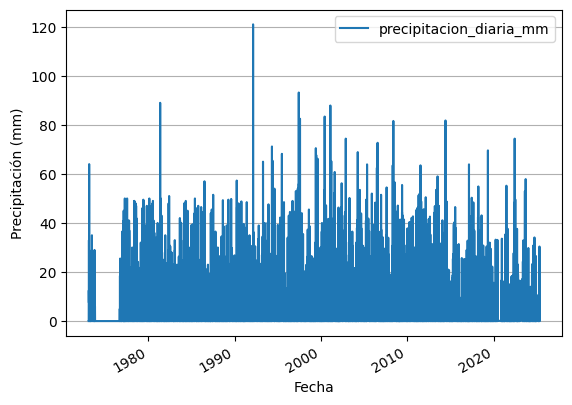

In [8]:
plt.figure(figsize=(12,5))
PMontt.plot()#no lo hacemos como barras por la carga computacional
plt.xlabel("Fecha")
plt.ylabel("Precipitación (mm)")
plt.grid(axis="y")

plt.show()


## Relleno de datos

Cuando faltan datos diarios, mensuales o anuales en una estación pluviométrica (𝑃_𝑥), se pueden estimar usando información simultánea de al menos tres estaciones cercanas con alta correlación temporal.


### Método 1

𝑃_𝑥=(𝑃_𝑎+𝑃_𝑏+𝑃_𝑐)/3  (estaciones climáticamente similares)
Si el modulo pluviometrico entre estaciones difiere en menos del 10 %

<Figure size 1500x600 with 0 Axes>

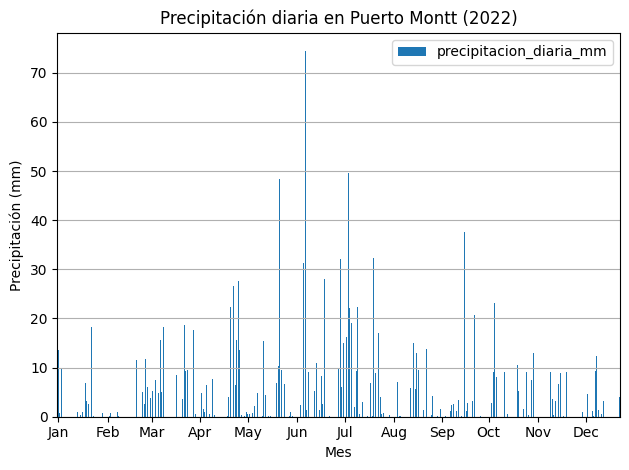

In [9]:

plt.figure(figsize=(15,6))
data_to_plot = PMontt.loc["2022"]
ax = data_to_plot.plot(kind="bar")
# Etiquetas
plt.xlabel("Mes")
plt.ylabel("Precipitación (mm)")
plt.title("Precipitación diaria en Puerto Montt (2022)")
# Mostrar solo un label por mes
dates = data_to_plot.index
month_positions = [i for i, d in enumerate(dates) if d.day == 1]
month_labels = [d.strftime('%b') for d in dates if d.day == 1]  # Ene, Feb, Mar...
ax.set_xticks(month_positions)
ax.set_xticklabels(month_labels, rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

<Figure size 1500x600 with 0 Axes>

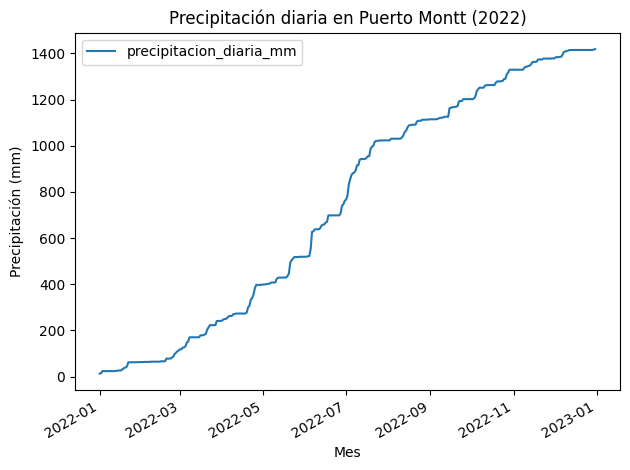

In [10]:
plt.figure(figsize=(15,6))
data_to_plot = PMontt.loc["2022"].cumsum()
ax = data_to_plot.plot()
# Etiquetas
plt.xlabel("Mes")
plt.ylabel("Precipitación (mm)")
plt.title("Precipitación diaria en Puerto Montt (2022)")
plt.tight_layout()
plt.show()

Vamos a rellenar los primeros 15 días, es decir del 1 al 15 de junio de 2020

In [11]:
PMontt_original = PMontt.copy()

# Reemplazar con NaN desde el 1 al 15 de julio de 2022
PMontt.loc["2022-07-01":"2022-07-15"] = np.nan

<Figure size 1500x600 with 0 Axes>

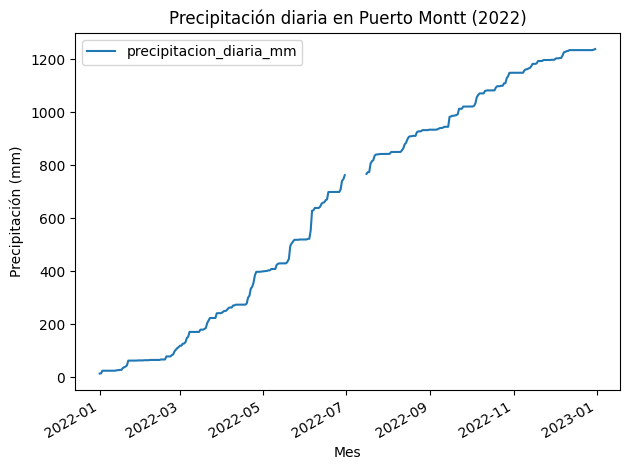

In [12]:
plt.figure(figsize=(15,6))
data_to_plot = PMontt.loc["2022"].cumsum()
ax = data_to_plot.plot()
# Etiquetas
plt.xlabel("Mes")
plt.ylabel("Precipitación (mm)")
plt.title("Precipitación diaria en Puerto Montt (2022)")
plt.tight_layout()
plt.show()

<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/PMontt_estaciones_cercanas.png" width="800">
</p>

https://explorador.cr2.cl/

In [13]:
def preparar_serie_precipitacion(df):
    df = df.copy()

    # limpiar nombres de columnas
    df.columns = df.columns.str.strip().str.lower()

    # renombrar por seguridad
    df = df.rename(columns={
        "agno": "anio",
        "año": "anio",
        "ano": "anio",
        "mes": "mes",
        "dia": "dia",
        "día": "dia",
        "valor": "precipitacion_diaria_mm",
        "precipitacion": "precipitacion_diaria_mm",
        "precipitación": "precipitacion_diaria_mm",
        "precipitacion_diaria": "precipitacion_diaria_mm"
    })

    # convertir columnas a numéricas
    for col in ["anio", "mes", "dia", "precipitacion_diaria_mm"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # eliminar filas con datos faltantes en columnas clave
    df = df.dropna(subset=["anio", "mes", "dia", "precipitacion_diaria_mm"])

    # convertir año, mes y día a enteros
    df["anio"] = df["anio"].astype(int)
    df["mes"] = df["mes"].astype(int)
    df["dia"] = df["dia"].astype(int)

    # crear columna fecha
    df["fecha"] = pd.to_datetime(
        dict(year=df["anio"], month=df["mes"], day=df["dia"]),
        errors="coerce"
    )

    # eliminar fechas inválidas
    df = df.dropna(subset=["fecha"])

    # dejar solo serie temporal final
    df = df[["fecha", "precipitacion_diaria_mm"]].copy()

    # ordenar y usar fecha como índice
    df = df.sort_values("fecha").reset_index(drop=True)
    df = df.set_index("fecha")

    return df

In [14]:
LagoChapo_raw = pd.read_excel("Data/Precipitación/LagoChapo_DGA_10430005.xlsx")
Puelo_raw = pd.read_excel("Data/Precipitación/Puelo_DGA_10523001.xlsx")
Tepual_raw = pd.read_excel("Data/Precipitación/Tepual_DMC_410005.xlsx")
Cascada_raw = pd.read_excel("Data/Precipitación/Cascada_DGA_10410015.xlsx")

LagoChapo = preparar_serie_precipitacion(LagoChapo_raw)
Puelo = preparar_serie_precipitacion(Puelo_raw)
Tepual = preparar_serie_precipitacion(Tepual_raw)
Cascada = preparar_serie_precipitacion(Cascada_raw)

In [15]:
df_corr = pd.concat(
    [
        PMontt["precipitacion_diaria_mm"].rename("PuertoMontt"),
        LagoChapo["precipitacion_diaria_mm"].rename("LagoChapo"),
        Puelo["precipitacion_diaria_mm"].rename("Puelo"),
        Tepual["precipitacion_diaria_mm"].rename("Tepual"),
        Cascada["precipitacion_diaria_mm"].rename("Cascada")
    ],
    axis=1
)

correlaciones = df_corr.corr()["PuertoMontt"].sort_values(ascending=False)

correlaciones

,PuertoMontt
PuertoMontt,1.000000
Tepual,0.835983
Puelo,0.788956
LagoChapo,0.561920
Cascada,0.538062


Vamos entonces a seleccionar las tres estaciones con mayor correlación para rellenar la precipitacion en el periodo eliminado de Puerto Montt

In [21]:
# Unir todas las estaciones en un solo DataFrame usando la fecha como índice
df_todas_estaciones = pd.concat(
    [
        PMontt["precipitacion_diaria_mm"].rename("PuertoMontt"),
        PMontt_original["precipitacion_diaria_mm"].rename("PuertoMontt_original"),
        Tepual["precipitacion_diaria_mm"].rename("Tepual"),
        Puelo["precipitacion_diaria_mm"].rename("Puelo"),
        LagoChapo["precipitacion_diaria_mm"].rename("LagoChapo"),

    ],
    axis=1
)

# Ver primeras filas
df_todas_estaciones.loc['2022-06-28':'2022-07-20']

,PuertoMontt,PuertoMontt_original,Tepual,Puelo,LagoChapo
fecha,,,,,
2022-06-28,32.0,32.0,20.0,37.5,22.6
2022-06-29,6.0,6.0,5.4,11.4,10.1
2022-06-30,15.1,15.1,13.6,11.4,21.3
2022-07-01,NaN,5.5,3.8,9.6,8.4
2022-07-02,NaN,16.2,16.6,28.8,19.3
2022-07-03,NaN,49.6,36.0,60.8,31.1
2022-07-04,NaN,22.1,17.6,32.6,7.6
2022-07-05,NaN,19.0,15.0,31.1,15.9
2022-07-06,NaN,7.6,7.2,21.4,10.5


In [24]:
# -----------------------------------------
# Crear columna SOLO con valores estimados
# para el período 1–15 julio 2022
# -----------------------------------------

# Inicializar columna vacía
df_todas_estaciones["Relleno_PM"] = np.nan

# Definir período
periodo_relleno = slice("2022-07-01", "2022-07-15")

# Calcular relleno por promedio simple
df_todas_estaciones.loc[periodo_relleno, "Relleno_PM"] = (
    df_todas_estaciones.loc[periodo_relleno, ["Tepual", "Puelo", "LagoChapo"]]
    .mean(axis=1)
)

# Ver resultados
df_todas_estaciones.loc[
    periodo_relleno,
    ["PuertoMontt_original","PuertoMontt", "Relleno_PM", "Tepual", "Puelo", "LagoChapo"]
]

,PuertoMontt_original,PuertoMontt,Relleno_PM,Tepual,Puelo,LagoChapo
fecha,,,,,,
2022-07-01,5.5,NaN,7.266667,3.8,9.6,8.4
2022-07-02,16.2,NaN,21.566667,16.6,28.8,19.3
2022-07-03,49.6,NaN,42.633333,36.0,60.8,31.1
2022-07-04,22.1,NaN,19.266667,17.6,32.6,7.6
2022-07-05,19.0,NaN,20.666667,15.0,31.1,15.9
2022-07-06,7.6,NaN,13.033333,7.2,21.4,10.5
2022-07-07,2.0,NaN,2.733333,1.2,5.3,1.7
2022-07-08,9.3,NaN,16.033333,6.4,20.2,21.5
2022-07-09,22.3,NaN,13.566667,9.6,13.6,17.5


### Método 2

Si el modulo pluviometrico entre estaciones difiere es mayor al 10 %
Otro metoddo mas robusto
𝑃_𝑥/𝑀_𝑥 =(𝑃_𝑎/𝑀_𝑎 +𝑃_𝑏/𝑀_𝑏 +𝑃_𝑐/𝑀_𝑐 )/3  donde 𝑀_𝑖 es el promedio histórico anual

In [30]:
# -----------------------------------------
# Método robusto: razón normal
# Px/Mx = promedio(Pi/Mi)
# M = precipitación media anual histórica
# -----------------------------------------

# 1. Calcular precipitación anual por estación
precipitacion_anual = df_todas_estaciones[
    ["PuertoMontt", "Tepual", "Puelo", "LagoChapo"]
].resample("Y").sum(min_count=300)

# 2. Calcular módulo pluviométrico: precipitación media anual histórica
modulos = precipitacion_anual.mean()

modulos

# 3. Extraer módulos
Mx = modulos["PuertoMontt"]
Ma = modulos["Tepual"]
Mb = modulos["Puelo"]
Mc = modulos["LagoChapo"]

# 4. Crear columna vacía para relleno con método robusto
df_todas_estaciones["Relleno_PM_modulo"] = np.nan

# 5. Definir período a rellenar
periodo_relleno = slice("2022-07-01", "2022-07-15")

# 6. Aplicar método ponderado por módulo
df_todas_estaciones.loc[periodo_relleno, "Relleno_PM_modulo"] = Mx * (
    (
        df_todas_estaciones.loc[periodo_relleno, "Tepual"] / Ma
        + df_todas_estaciones.loc[periodo_relleno, "Puelo"] / Mb
        + df_todas_estaciones.loc[periodo_relleno, "LagoChapo"] / Mc
    ) / 3
)

# 7. Ver comparación
df_todas_estaciones.loc[
    periodo_relleno,
    [
        "PuertoMontt_original",
        "PuertoMontt",
        "Relleno_PM",
        "Relleno_PM_modulo",
        "Tepual",
        "Puelo",
        "LagoChapo"
    ]
]

/tmp/ipykernel_12414/3256027702.py:10: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  ].resample("Y").sum(min_count=300)


,PuertoMontt_original,PuertoMontt,Relleno_PM,Relleno_PM_modulo,Tepual,Puelo,LagoChapo
fecha,,,,,,,
2022-07-01,5.5,NaN,7.266667,5.556052,3.8,9.6,8.4
2022-07-02,16.2,NaN,21.566667,17.023123,16.6,28.8,19.3
2022-07-03,49.6,NaN,42.633333,33.832215,36.0,60.8,31.1
2022-07-04,22.1,NaN,19.266667,15.232867,17.6,32.6,7.6
2022-07-05,19.0,NaN,20.666667,16.088097,15.0,31.1,15.9
2022-07-06,7.6,NaN,13.033333,9.847273,7.2,21.4,10.5
2022-07-07,2.0,NaN,2.733333,2.002870,1.2,5.3,1.7
2022-07-08,9.3,NaN,16.033333,12.092723,6.4,20.2,21.5
2022-07-09,22.3,NaN,13.566667,10.792174,9.6,13.6,17.5


Compracion de curvas acumuladas

<Figure size 1500x600 with 0 Axes>

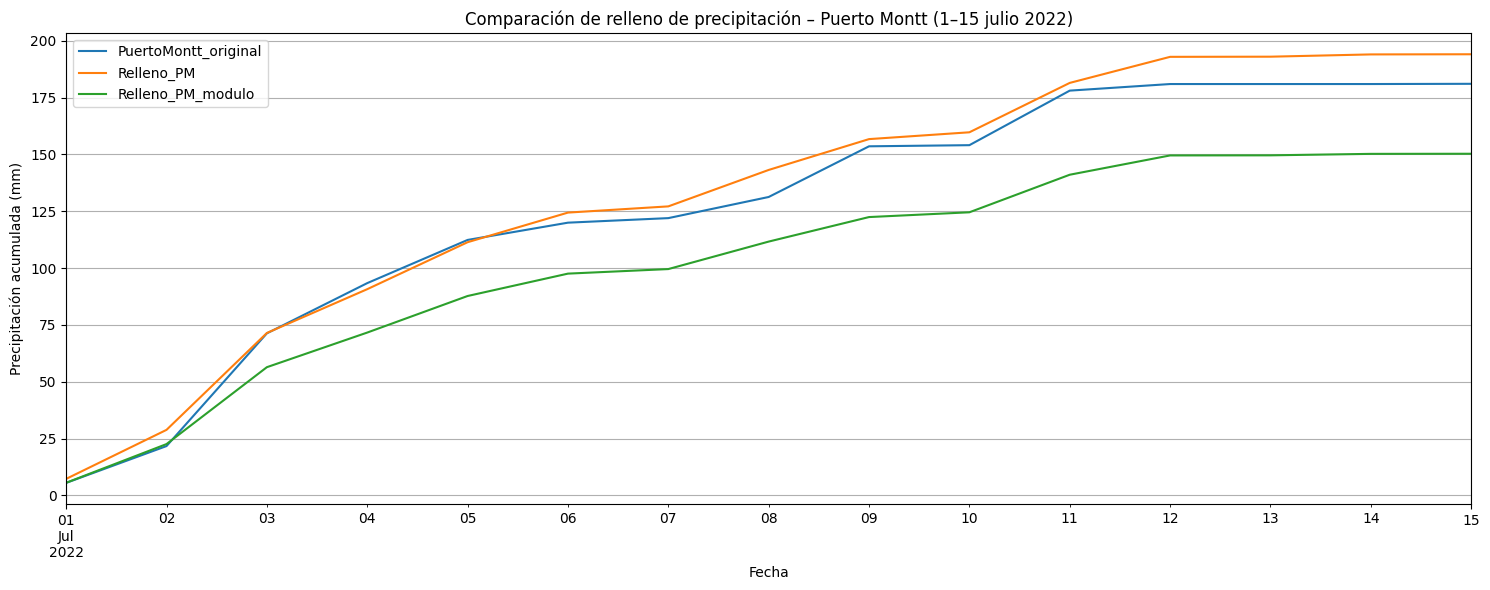

In [39]:
plt.figure(figsize=(15,6))

# Seleccionar período y columnas correctamente
data_to_plot = df_todas_estaciones.loc[
    "2022-07-01":"2022-07-15",
    ["PuertoMontt_original", "Relleno_PM", "Relleno_PM_modulo"]
].cumsum()

# Graficar
ax = data_to_plot.plot(figsize=(15,6))

# Etiquetas
plt.xlabel("Fecha")
plt.ylabel("Precipitación acumulada (mm)")
plt.title("Comparación de relleno de precipitación – Puerto Montt (1–15 julio 2022)")



plt.grid(True)
plt.tight_layout()
plt.show()

## Homogeneidad

### Curva de doble masa:

Sirven para la evaluación de consistencia y homogeneidad de series pluviométricas.
**La curva de doble masa permite distinguir entre cambios climáticos reales y alteraciones artificiales en la medición.**

Las series de precipitación registradas en una estación pueden verse afectadas por factores distintos a cambios climáticos reales. Alteraciones en el entorno (urbanización, vegetación, obstáculos), cambio de ubicación de la estación, reemplazo del instrumento o variaciones en el observador pueden generar modificaciones artificiales en los datos medidos, produciendo aumentos o disminuciones que no representan necesariamente cambios verdaderos en la precipitación.

Para detectar estas posibles inconsistencias, se utiliza el método de la **curva de doble masa**, una herramienta clásica para evaluar la homogeneidad de una serie pluviométrica.


#### Principio del método

El procedimiento consiste en comparar la **precipitación acumulada de la estación en análisis** con la **precipitación acumulada de una serie patrón**, generalmente construida a partir del promedio de varias estaciones vecinas representativas.

Si la estación mantiene condiciones homogéneas y la región presenta comportamiento pluviométrico similar, ambas series deberían guardar una relación proporcional:

$$
P_x = \alpha P_p + \varepsilon
$$

Donde:

- $P_x$: precipitación de la estación analizada  
- $P_p$: precipitación patrón (promedio de estaciones vecinas)  
- $\alpha$: constante de proporcionalidad  
- $\varepsilon$: error aleatorio o dispersión residual  

Al acumular en el tiempo:

$$
\sum P_x \approx \alpha \sum P_p
$$

Como los errores aleatorios tienden a compensarse, una estación homogénea debería producir una relación aproximadamente lineal.


#### Interpretación de la curva

**Serie homogénea:**  
Si la curva acumulada es aproximadamente una línea recta que pasa por el origen, la estación mantiene una relación estable con el patrón y sus datos pueden considerarse consistentes.

**Cambio de pendiente:**  
Si aparecen dos o más tramos con pendientes distintas, esto puede indicar cambios en las condiciones de medición, tales como:

- Cambio de instrumento  
- Reubicación  
- Modificaciones ambientales  
- Problemas operacionales  

Una pendiente mayor puede sugerir sobreestimación, mientras que una menor puede indicar subestimación respecto al patrón.


#### Corrección de series

Si se detecta una discontinuidad clara y persistente, los datos pueden ajustarse mediante:

$$
P_c = P_m \frac{\alpha_1}{\alpha_i}
$$

Donde:

- $P_c$: precipitación corregida  
- $P_m$: precipitación medida  
- $\alpha_i$: pendiente del tramo inconsistente  
- $\alpha_1$: pendiente del período de referencia  

Por convención, suele usarse como referencia el período más reciente o el más confiable.

#### Recomendaciones prácticas

- No corregir cambios poco notorios  
- Evitar ajustes si la anomalía dura menos de ~5 años  
- Investigar causas físicas o instrumentales antes de corregir  
- Revisar también la homogeneidad de las estaciones patrón  
- Aplicar el proceso de forma iterativa  


#### Desplazamientos bruscos

Si la curva presenta un salto vertical abrupto pero mantiene la misma pendiente, esto suele indicar un error puntual importante en uno o pocos registros, más que una alteración estructural del sistema de medición.

### Resumen visual

- **Recta continua:** serie homogénea  
- **Cambio de pendiente:** posible inhomogeneidad  
- **Salto brusco:** error puntual probable  

Este análisis es fundamental antes de realizar estudios de tendencias, extremos, relleno de datos faltantes o evaluación climática de largo plazo.

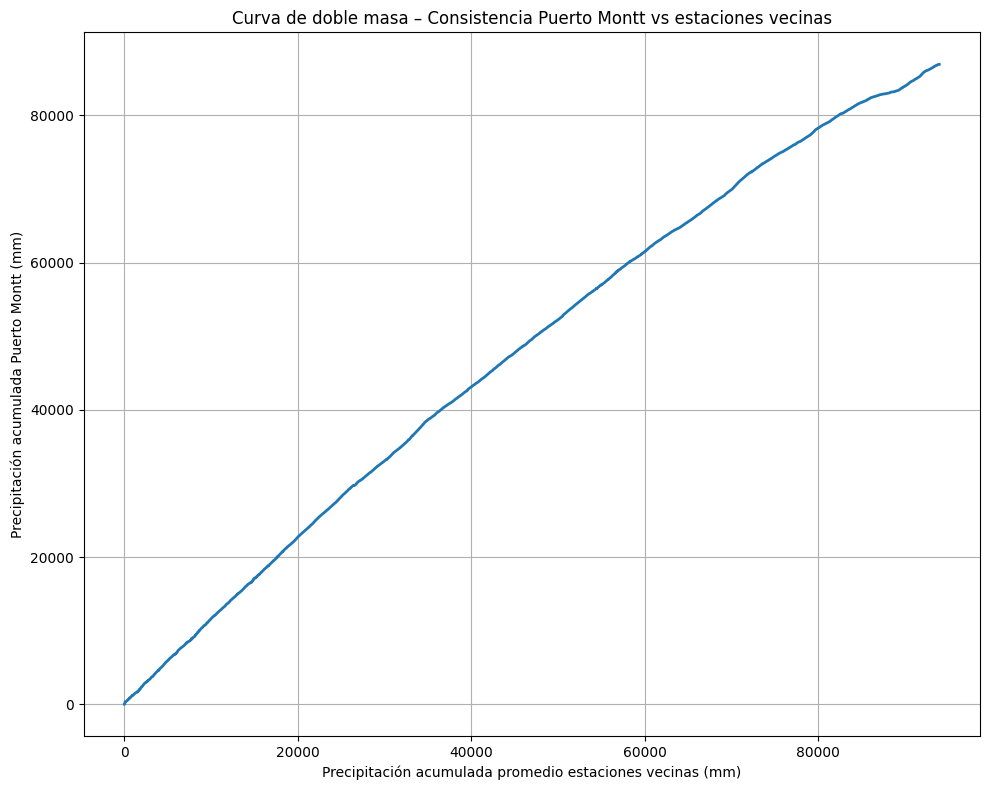

In [44]:
# -----------------------------------------
# Curva de doble masa:
# Puerto Montt vs promedio acumulado de estaciones vecinas
# -----------------------------------------

# 1. Crear serie promedio de estaciones vecinas
df_todas_estaciones["Promedio_vecinas"] = df_todas_estaciones[
    ["Tepual", "Puelo", "LagoChapo"]
].mean(axis=1)

# 2. Seleccionar solo fechas con datos completos
df_doble_masa = df_todas_estaciones[
    ["PuertoMontt_original", "Promedio_vecinas"]
].dropna()

# 3. Calcular acumulados
df_doble_masa["PuertoMontt_acum"] = df_doble_masa["PuertoMontt_original"].cumsum()
df_doble_masa["Vecinas_acum"] = df_doble_masa["Promedio_vecinas"].cumsum()

# 4. Graficar curva de doble masa
plt.figure(figsize=(10,8))

plt.plot(
    df_doble_masa["Vecinas_acum"],
    df_doble_masa["PuertoMontt_acum"],
    linewidth=2
)

# Línea de referencia ideal
xmin = df_doble_masa["Vecinas_acum"].min()
xmax = df_doble_masa["Vecinas_acum"].max()
ymin = df_doble_masa["PuertoMontt_acum"].min()
ymax = df_doble_masa["PuertoMontt_acum"].max()

plt.xlabel("Precipitación acumulada promedio estaciones vecinas (mm)")
plt.ylabel("Precipitación acumulada Puerto Montt (mm)")
plt.title("Curva de doble masa – Consistencia Puerto Montt vs estaciones vecinas")

plt.grid(True)
plt.tight_layout()
plt.show()

La relación es bastante lineal durante gran parte del registro.

👉 Esto sugiere que la serie de Puerto Montt es consistente respecto a las estaciones vecinas.

En términos prácticos:
No hay evidencia fuerte de cambios abruptos en instrumento
No se observan quiebres grandes por cambio de ubicación
No hay señales claras de sesgos sistemáticos mayores

<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/Curva_doble_masa_1.png" width="500">
</p>
<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/Curva_doble_masa_2.png" width="500">
</p>





## Intensidad de precipitación